In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.preprocessing import robust_scale,minmax_scale
from sklearn.model_selection import KFold

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.regularizers import L1L2, L1, L2
from tensorflow.keras.optimizers import Adam

Matplotlib is building the font cache; this may take a moment.
/Users/andrescubillovillalobos/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [3]:
data = pd.read_csv("./../Data_Demo/input_train_no_lnc_features.csv", header=None)

In [4]:
data

,0,1,2,3,4,5,6,7,8,9,...,677,678,679,680,681,682,683,684,685,686
0,84,600,10.0,1.0,3.0,-890.0,-23.530001,12.0,22.0,31.0,...,2.0,4.0,2.0,5.0,6.0,1.0,2.0,0.0,1.0,2.0
1,63,600,5.0,0.0,0.0,-680.0,-17.620001,18.0,11.0,13.0,...,2.0,4.0,2.0,5.0,6.0,1.0,2.0,0.0,1.0,2.0
2,78,600,10.0,1.0,3.0,-890.0,-27.389999,10.0,15.0,23.0,...,2.0,4.0,2.0,5.0,6.0,1.0,2.0,0.0,1.0,2.0
3,96,600,10.0,1.0,3.0,-890.0,-24.360001,8.0,38.0,34.0,...,2.0,4.0,2.0,5.0,6.0,1.0,2.0,0.0,1.0,2.0
4,82,3043,8.0,0.0,7.0,-1160.0,-12.670000,16.0,18.0,19.0,...,5.0,10.0,6.0,4.0,11.0,2.0,3.0,9.0,6.0,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45972,115,588,-1.0,-1.0,-1.0,0.0,0.000000,30.0,18.0,27.0,...,0.0,2.0,2.0,4.0,5.0,3.0,3.0,3.0,3.0,1.0
45973,71,2036,17.0,1.0,8.0,-290.0,-13.590000,20.0,11.0,16.0,...,4.0,17.0,13.0,9.0,10.0,19.0,19.0,14.0,20.0,32.0
45974,73,795,15.0,0.0,2.0,-1760.0,-22.610001,17.0,17.0,18.0,...,0.0,3.0,2.0,3.0,3.0,12.0,4.0,4.0,11.0,14.0
45975,78,4296,7.0,0.0,14.0,2120.0,-13.220000,22.0,9.0,15.0,...,3.0,20.0,22.0,16.0,15.0,8.0,19.0,14.0,22.0,42.0


In [5]:
negative_pairs_path = "./../Data_Demo/txt_interac/negative_pairs.txt"
positive_pairs_path = "./../Data_Demo/txt_interac/mirnas_lncrnas_validated_positive_pairs.txt"

positive_pairs = [[line.strip().split(",")[0],line.strip().split(",")[1]] for line in open(positive_pairs_path,"r").readlines()]
negative_pairs = [[line.strip().split(",")[0],line.strip().split(",")[1]] for line in open(negative_pairs_path,"r").readlines()]

labels = [1] * len(positive_pairs) + [0] * len(negative_pairs)
labels = pd.DataFrame(labels)

del positive_pairs
del negative_pairs

In [6]:
train_data, test_data, train_label, test_label = train_test_split(data, labels, test_size=0.25, random_state=42)
dim = len(train_data.columns)

In [7]:
k =  5
kf = KFold(n_splits=k,shuffle=True,random_state=42)
histories = []
scores = []

In [8]:
def get_model():
    model = Sequential()
    model.add(BatchNormalization(input_shape = (dim,)))
    model.add(Dense(150,activation = 'relu', bias_initializer='zeros', kernel_initializer = 'he_normal', kernel_regularizer=L2(0.002)))
    model.add(Dropout(0.3))
    model.add(Dense(75,activation = 'relu', bias_initializer='zeros', kernel_initializer = 'he_normal', kernel_regularizer=L2(0.002)))
    model.add(Dropout(0.3))
    model.add(Dense(20,activation = 'relu', bias_initializer='zeros', kernel_initializer = 'he_normal', kernel_regularizer=L2(0.002)))
    model.add(Dropout(0.3))
    model.add(Dense(1,activation = 'sigmoid', bias_initializer = 'zeros', kernel_initializer = 'glorot_normal'))
    return model

Epoch 1/100


/Users/andrescubillovillalobos/Library/Python/3.9/lib/python/site-packages/keras/src/layers/normalization/batch_normalization.py:142: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5680 - loss: 1.8260 - val_accuracy: 0.7422 - val_loss: 1.4752
Epoch 2/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7184 - loss: 1.4073 - val_accuracy: 0.8599 - val_loss: 1.1269
Epoch 3/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8379 - loss: 1.1308 - val_accuracy: 0.8705 - val_loss: 0.9809
Epoch 4/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8690 - loss: 0.9773 - val_accuracy: 0.8726 - val_loss: 0.8740
Epoch 5/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8747 - loss: 0.8665 - val_accuracy: 0.8750 - val_loss: 0.7783
Epoch 6/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8810 - loss: 0.7631 - val_accuracy: 0.8749 - val_loss: 0.6973
Epoch 7/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8811 - loss: 0.6781 - val_accuracy: 0.8750 - val_loss: 0.6294
Epoch 8/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8807 - loss: 0.6140 - val_accuracy: 0.8750

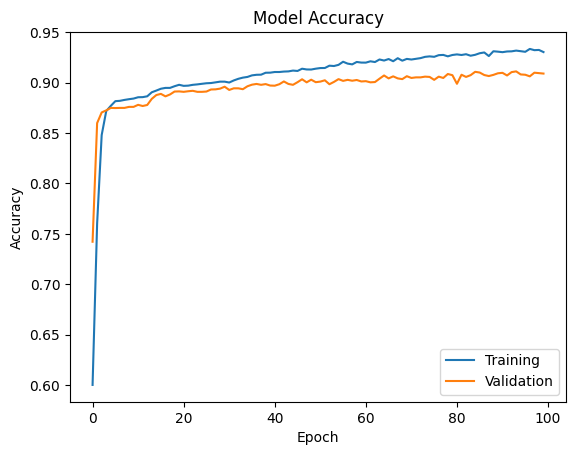

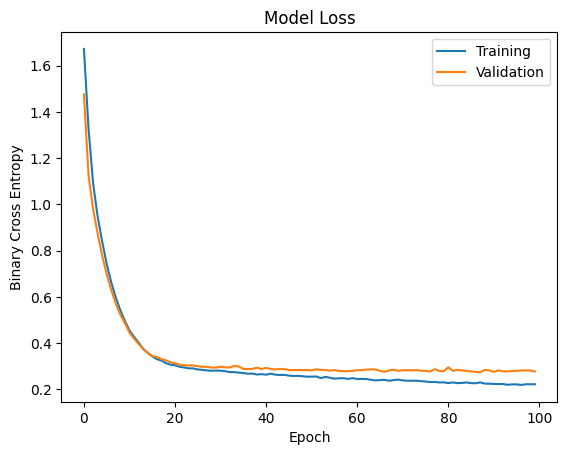

Epoch 1/100


/Users/andrescubillovillalobos/Library/Python/3.9/lib/python/site-packages/keras/src/layers/normalization/batch_normalization.py:142: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5951 - loss: 1.7266 - val_accuracy: 0.7856 - val_loss: 1.3987
Epoch 2/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7537 - loss: 1.3407 - val_accuracy: 0.8823 - val_loss: 1.0609
Epoch 3/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8448 - loss: 1.0828 - val_accuracy: 0.8860 - val_loss: 0.9168
Epoch 4/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8698 - loss: 0.9269 - val_accuracy: 0.8879 - val_loss: 0.8055
Epoch 5/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8752 - loss: 0.8084 - val_accuracy: 0.8901 - val_loss: 0.7053
Epoch 6/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8803 - loss: 0.7077 - val_accuracy: 0.8860 - val_loss: 0.6349
Epoch 7/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8788 - loss: 0.6348 - val_accuracy: 0.8913 - val_loss: 0.5578
Epoch 8/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8854 - loss: 0.5620 - val_accuracy: 0.8911

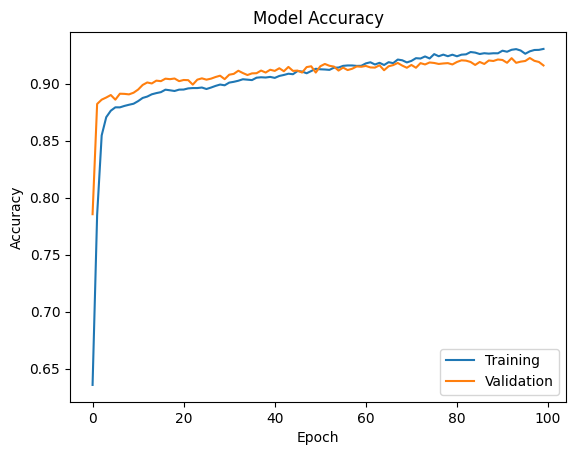

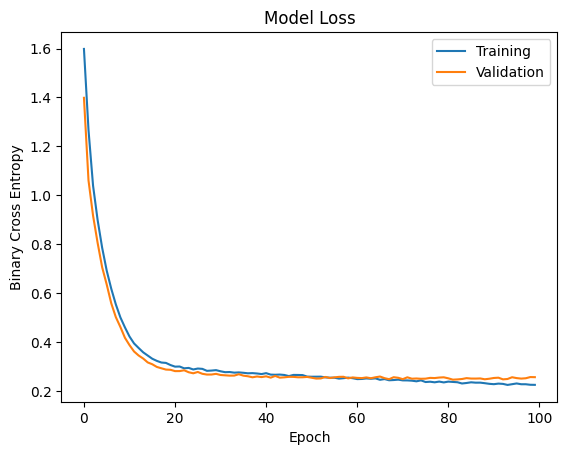

Epoch 1/100


/Users/andrescubillovillalobos/Library/Python/3.9/lib/python/site-packages/keras/src/layers/normalization/batch_normalization.py:142: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5897 - loss: 1.6644 - val_accuracy: 0.7699 - val_loss: 1.3829
Epoch 2/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7577 - loss: 1.3156 - val_accuracy: 0.8794 - val_loss: 1.0254
Epoch 3/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8571 - loss: 1.0425 - val_accuracy: 0.8860 - val_loss: 0.8824
Epoch 4/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8740 - loss: 0.8911 - val_accuracy: 0.8865 - val_loss: 0.7726
Epoch 5/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8754 - loss: 0.7808 - val_accuracy: 0.8865 - val_loss: 0.6776
Epoch 6/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8800 - loss: 0.6799 - val_accuracy: 0.8866 - val_loss: 0.6001
Epoch 7/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8796 - loss: 0.6041 - val_accuracy: 0.8875 - val_loss: 0.5343
Epoch 8/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8788 - loss: 0.5412 - val_accuracy: 0.8876

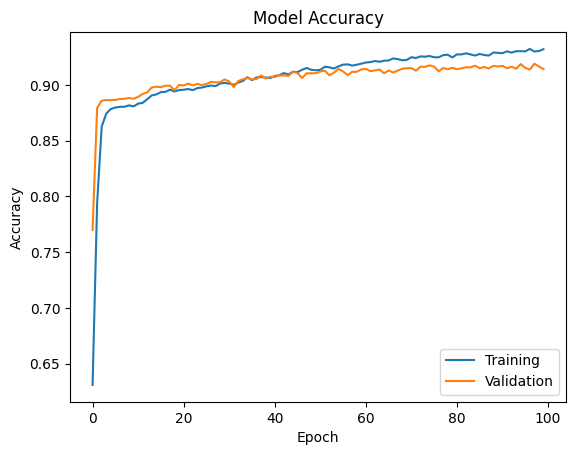

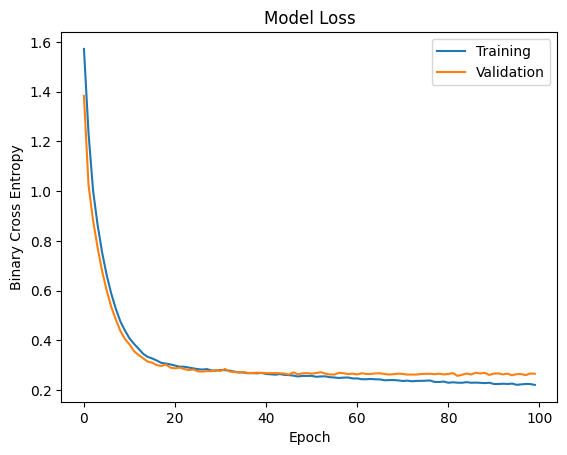

Epoch 1/100


/Users/andrescubillovillalobos/Library/Python/3.9/lib/python/site-packages/keras/src/layers/normalization/batch_normalization.py:142: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5694 - loss: 1.7506 - val_accuracy: 0.7674 - val_loss: 1.4141
Epoch 2/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7472 - loss: 1.3556 - val_accuracy: 0.8747 - val_loss: 1.0809
Epoch 3/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8539 - loss: 1.0868 - val_accuracy: 0.8840 - val_loss: 0.9328
Epoch 4/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8739 - loss: 0.9344 - val_accuracy: 0.8847 - val_loss: 0.8234
Epoch 5/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8785 - loss: 0.8183 - val_accuracy: 0.8844 - val_loss: 0.7321
Epoch 6/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8764 - loss: 0.7262 - val_accuracy: 0.8838 - val_loss: 0.6475
Epoch 7/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8827 - loss: 0.6405 - val_accuracy: 0.8863 - val_loss: 0.5748
Epoch 8/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8787 - loss: 0.5751 - val_accuracy: 0.8866

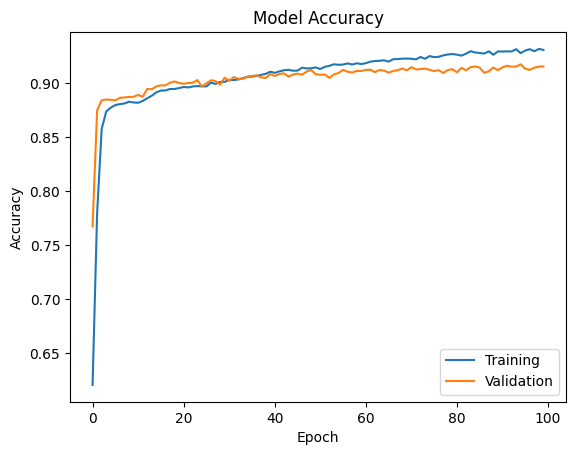

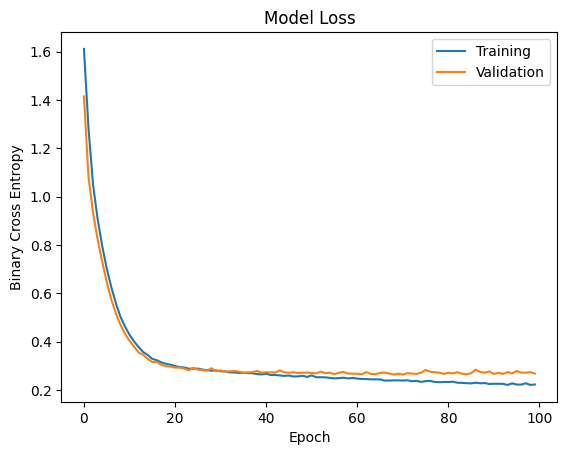

Epoch 1/100


/Users/andrescubillovillalobos/Library/Python/3.9/lib/python/site-packages/keras/src/layers/normalization/batch_normalization.py:142: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5899 - loss: 1.7383 - val_accuracy: 0.7680 - val_loss: 1.4209
Epoch 2/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7364 - loss: 1.3705 - val_accuracy: 0.8651 - val_loss: 1.0924
Epoch 3/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8462 - loss: 1.1036 - val_accuracy: 0.8701 - val_loss: 0.9569
Epoch 4/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8725 - loss: 0.9391 - val_accuracy: 0.8746 - val_loss: 0.8398
Epoch 5/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8800 - loss: 0.8225 - val_accuracy: 0.8735 - val_loss: 0.7500
Epoch 6/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8792 - loss: 0.7296 - val_accuracy: 0.8750 - val_loss: 0.6668
Epoch 7/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8824 - loss: 0.6463 - val_accuracy: 0.8750 - val_loss: 0.5978
Epoch 8/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8867 - loss: 0.5717 - val_accuracy: 0.8750

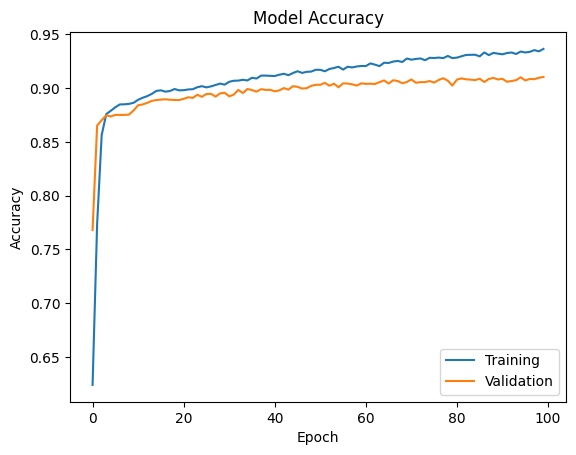

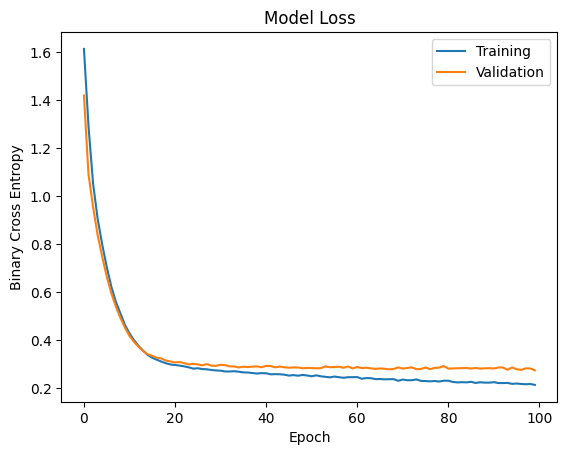

In [9]:
for train_index, test_index in kf.split(train_data):
    data_train, data_val = train_data.iloc[train_index], train_data.iloc[test_index]
    label_train, label_val = train_label.iloc[train_index], train_label.iloc[test_index]

    model = get_model()
    opt = Adam(0.0005)
    model.compile(optimizer=opt,loss='binary_crossentropy', metrics=['accuracy'])
    history = model.fit(data_train,label_train,batch_size=256,epochs=100, validation_data = (data_val, label_val))
    
    score = model.evaluate(data_val, label_val)
    histories.append(history)
    scores.append(scores)

    # summarize history for accuracy
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title('Model Accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(['Training', 'Validation'], loc='lower right')
    plt.show()

    # summarize history for loss
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title('Model Loss')
    plt.ylabel('Binary Cross Entropy')
    plt.xlabel('Epoch')
    plt.legend(['Training', 'Validation'], loc='upper right')
    plt.show()

In [10]:
%pip install tensorflow scikit-learn matplotlib seaborn numpy

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.
